# BayBE Optimizer Worked Example (Notebook Interface)

This notebook mirrors the Streamlit GUI workflow in a notebook-friendly form.

It covers:
- defining parameters and encodings
- choosing initialization strategy (Sobol or existing CSV)
- choosing a BayBE acquisition function
- visualizing the exploration ↔ exploitation spectrum of the acquisition choices
- adjusting `beta` for UCB/qUCB
- recommending and ingesting batches while persisting JSON + CSV artifacts

Edit the configuration cells and run top-to-bottom.

In [2]:
from __future__ import annotations

import json
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Literal, Optional

import matplotlib.pyplot as plt
import pandas as pd

from baybe.acquisition.utils import str_to_acqf
from baybe.campaign import Campaign
from baybe.objectives import SingleTargetObjective
from baybe.parameters import CategoricalParameter, NumericalContinuousParameter, NumericalDiscreteParameter
from baybe.parameters.substance import SubstanceParameter
from baybe.parameters.enum import SubstanceEncoding
from baybe.recommenders import BotorchRecommender
from baybe.searchspace import SearchSpace
from baybe.targets import NumericalTarget


In [3]:
@dataclass
class ParameterSpec:
    name: str


@dataclass
class NumericalContinuousSpec(ParameterSpec):
    lower: float
    upper: float
    unit: Optional[str] = None


@dataclass
class NumericalDiscreteSpec(ParameterSpec):
    values: List[float]
    unit: Optional[str] = None
    tolerance: float = 0.0


@dataclass
class CategoricalSpec(ParameterSpec):
    values: List[str]
    encoding: Literal["OHE", "INT"] = "OHE"


@dataclass
class SubstanceSpec(ParameterSpec):
    smiles: List[str] = field(default_factory=list)
    encoding: str = "MORDRED"
    decorrelate: bool = True


@dataclass
class CampaignConfig:
    campaign_name: str = "demo_campaign"
    objective_target: str = "yield"
    objective_mode: Literal["maximize", "minimize"] = "maximize"
    batch_size: int = 8
    init_mode: Literal["sobol", "existing_data"] = "sobol"
    n_init: int = 8
    acquisition: str = "qExpectedImprovement"
    acquisition_kwargs: Dict[str, Any] = field(default_factory=lambda: {"best_f": None})
    parameters: List[ParameterSpec] = field(default_factory=list)


In [5]:
ACQ_INFO = {
    "ExpectedImprovement": {"score": 0.42, "label": "EI", "summary": "Balanced single-point default."},
    "ProbabilityOfImprovement": {"score": 0.25, "label": "PI", "summary": "More exploitative / greedy."},
    "UpperConfidenceBound": {"score": 0.68, "label": "UCB", "summary": "Explicit exploration knob via beta."},
    "qExpectedImprovement": {"score": 0.48, "label": "qEI", "summary": "Strong batch default for HTE."},
    "qProbabilityOfImprovement": {"score": 0.30, "label": "qPI", "summary": "Batch PI; more exploitative."},
    "qUpperConfidenceBound": {"score": 0.75, "label": "qUCB", "summary": "Batch UCB; explores more as beta grows."},
    "qThompsonSampling": {"score": 0.85, "label": "qTS", "summary": "Diverse, exploratory batches."},
    "qNoisyExpectedImprovement": {
    "score": 0.54,
    "label": "qNEI",
    "summary": "Like qEI, but more robust when measurements are noisy.",
}}


def plot_acquisition_scale(selected: str, beta: float | None = None):
    fig, ax = plt.subplots(figsize=(10, 1.8))
    ax.hlines(0, 0, 1, linewidth=6)
    for name, info in ACQ_INFO.items():
        score = info["score"]
        ax.scatter(score, 0, s=140 if name == selected else 80)
        ax.text(score, 0.08 if name == selected else -0.12, info["label"], ha="center", va="center", fontsize=9)

    if selected in {"UpperConfidenceBound", "qUpperConfidenceBound"} and beta is not None:
        dynamic = min(0.95, max(0.45, 0.55 + 0.12 * (beta ** 0.5)))
        ax.scatter(dynamic, 0, s=220, marker="*")
        ax.text(dynamic, 0.23, f"beta={beta:g}", ha="center", va="center", fontsize=9)

    ax.text(0, -0.28, "Exploitative", ha="left", va="center")
    ax.text(1, -0.28, "Exploratory", ha="right", va="center")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.4, 0.35)
    ax.axis("off")
    plt.show()

    print(f"{ACQ_INFO[selected]['label']}: {ACQ_INFO[selected]['summary']}")


In [6]:
def ensure_campaign_dirs(workdir: Path) -> None:
    for sub in ["plans", "results", "campaign_jsons"]:
        (workdir / sub).mkdir(parents=True, exist_ok=True)


def campaign_latest_path(workdir: Path, campaign_name: str) -> Path:
    return workdir / "campaign_jsons" / f"{campaign_name}_latest.json"


def campaign_snapshot_path(workdir: Path, campaign_name: str, tag: str) -> Path:
    return workdir / "campaign_jsons" / f"{campaign_name}_{tag}.json"


def run_plan_path(workdir: Path, run_idx: int) -> Path:
    return workdir / "plans" / f"run{run_idx}.csv"


def run_results_path(workdir: Path, run_idx: int) -> Path:
    return workdir / "results" / f"run{run_idx}_results.csv"


def all_runs_path(workdir: Path) -> Path:
    return workdir / "results" / "all_runs.csv"


def save_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def load_text(path: Path) -> str:
    return path.read_text(encoding="utf-8")


def append_all_runs(workdir: Path, df: pd.DataFrame, run_idx: int) -> None:
    out = all_runs_path(workdir)
    df2 = df.copy()
    df2["run_idx"] = run_idx
    if out.exists():
        old = pd.read_csv(out)
        pd.concat([old, df2], ignore_index=True).to_csv(out, index=False)
    else:
        df2.to_csv(out, index=False)


def discover_next_run_idx(workdir: Path) -> int:
    plans = sorted((workdir / "plans").glob("run*.csv"))
    if not plans:
        return 1
    idxs = []
    for p in plans:
        stem = p.stem.replace("run", "")
        if stem.isdigit():
            idxs.append(int(stem))
    return max(idxs, default=0) + 1


def measured_keys(workdir: Path, param_cols: List[str]) -> set[tuple]:
    out = all_runs_path(workdir)
    if not out.exists():
        return set()
    df = pd.read_csv(out)
    keep = [c for c in param_cols if c in df.columns]
    return set(tuple(row) for row in df[keep].itertuples(index=False, name=None))


def drop_measured(df: pd.DataFrame, keys: set[tuple], param_cols: List[str]) -> pd.DataFrame:
    keep = [c for c in param_cols if c in df.columns]
    mask = [tuple(row) not in keys for row in df[keep].itertuples(index=False, name=None)]
    return df.loc[mask].reset_index(drop=True)


In [7]:
def build_parameters(specs: List[ParameterSpec]):
    params = []
    for s in specs:
        if isinstance(s, NumericalContinuousSpec):
            md = {"unit": s.unit} if s.unit else None
            kwargs = {"metadata": md} if md is not None else {}
            params.append(NumericalContinuousParameter(name=s.name, bounds=(float(s.lower), float(s.upper)), **kwargs))
        elif isinstance(s, NumericalDiscreteSpec):
            md = {"unit": s.unit} if s.unit else None
            kwargs = {"metadata": md} if md is not None else {}
            params.append(NumericalDiscreteParameter(name=s.name, values=[float(v) for v in s.values], tolerance=s.tolerance, **kwargs))
        elif isinstance(s, CategoricalSpec):
            params.append(CategoricalParameter(name=s.name, values=list(s.values), encoding=s.encoding))
        elif isinstance(s, SubstanceSpec):
            params.append(SubstanceParameter(name=s.name, data={sm: sm for sm in s.smiles}, encoding=SubstanceEncoding[s.encoding]))
        else:
            raise TypeError(type(s))
    return params


def build_recommender(cfg: CampaignConfig) -> BotorchRecommender:
    alias = {
    "PI": "ProbabilityOfImprovement",
    "EI": "ExpectedImprovement",
    "qPI": "qProbabilityOfImprovement",
    "qEI": "qExpectedImprovement",
    "NEI": "qNoisyExpectedImprovement",
    "qNEI": "qNoisyExpectedImprovement",
    "UCB": "UpperConfidenceBound",
    "qUCB": "qUpperConfidenceBound",
    "TS": "qThompsonSampling",
    "qTS": "qThompsonSampling",
}
    acq_name = alias.get(cfg.acquisition, cfg.acquisition)
    acqf = str_to_acqf(acq_name, **(cfg.acquisition_kwargs or {}))
    return BotorchRecommender(acquisition_function=acqf)


def build_campaign(cfg: CampaignConfig) -> Campaign:
    searchspace = SearchSpace.from_product(build_parameters(cfg.parameters))
    target = NumericalTarget(name=cfg.objective_target, mode=cfg.objective_mode)
    objective = SingleTargetObjective(target=target)
    recommender = build_recommender(cfg)
    return Campaign(searchspace=searchspace, objective=objective, recommender=recommender)


## Configure the campaign

Edit this cell directly. For UCB/qUCB, set `acquisition_kwargs={"beta": ...}` to control exploration.

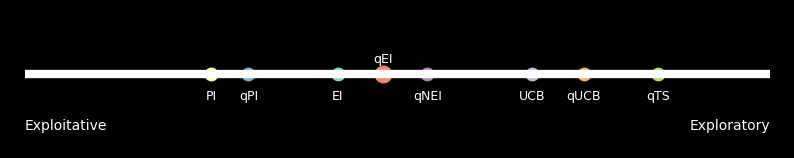

qEI: Strong batch default for HTE.


CampaignConfig(campaign_name='demo_campaign', objective_target='yield', objective_mode='maximize', batch_size=8, init_mode='sobol', n_init=8, acquisition='qExpectedImprovement', acquisition_kwargs={'best_f': None}, parameters=[CategoricalSpec(name='solvent', values=['MeCN', 'HFIP'], encoding='OHE'), NumericalDiscreteSpec(name='reaction_time', values=[1.0, 2.0, 3.0], unit='h', tolerance=0.0), NumericalDiscreteSpec(name='equiv', values=[1.0, 2.0, 3.0], unit=None, tolerance=0.0)])

In [8]:
cfg = CampaignConfig(
    campaign_name="demo_campaign",
    objective_target="yield",
    objective_mode="maximize",
    batch_size=8,
    init_mode="sobol",       # or "existing_data"
    n_init=8,
    acquisition = "qExpectedImprovement",
    # alternatives:
    # acquisition = "qNoisyExpectedImprovement"
    # acquisition = "qUpperConfidenceBound"
    # acquisition = "qThompsonSampling"
    acquisition_kwargs={"best_f": None},
    parameters=[
        CategoricalSpec(name="solvent", values=["MeCN", "HFIP"], encoding="OHE"),
        NumericalDiscreteSpec(name="reaction_time", values=[1.0, 2.0, 3.0], unit="h"),
        NumericalDiscreteSpec(name="equiv", values=[1.0, 2.0, 3.0]),
    ],
)

# Example for qUCB:
# cfg.acquisition = "qUpperConfidenceBound"
# cfg.acquisition_kwargs = {"beta": 4.0}

plot_acquisition_scale(cfg.acquisition, cfg.acquisition_kwargs.get("beta"))
cfg


## Initialize working directory

In [9]:
WORKDIR = Path('./baybe_notebook_demo').resolve()
ensure_campaign_dirs(WORKDIR)
latest = campaign_latest_path(WORKDIR, cfg.campaign_name)
print(WORKDIR)


C:\Users\timot\PycharmProjects\Alpine_GP\baybe_streamlit_gui_v3\baybe_notebook_demo


## Initialize the campaign

Choose one block:
- Sobol cold start: generate `plans/run0.csv`
- Existing data warm start: load a CSV containing parameter columns + `yield`

In [ ]:
# Sobol-style cold start using a simple random helper if you prefer to edit manually.
# If you already have run0 planned elsewhere, skip this cell.
from itertools import product


def simple_initial_design(specs: List[ParameterSpec], n: int, seed: int = 0) -> pd.DataFrame:
    rng = pd.Series(range(n)).sample(frac=1.0, random_state=seed).index  # deterministic shuffle seed
    cols = {}
    import random
    random.seed(seed)
    for s in specs:
        if isinstance(s, NumericalContinuousSpec):
            cols[s.name] = [random.uniform(s.lower, s.upper) for _ in range(n)]
        elif isinstance(s, NumericalDiscreteSpec):
            cols[s.name] = [random.choice(s.values) for _ in range(n)]
        elif isinstance(s, CategoricalSpec):
            cols[s.name] = [random.choice(s.values) for _ in range(n)]
        elif isinstance(s, SubstanceSpec):
            cols[s.name] = [random.choice(s.smiles) for _ in range(n)]
    return pd.DataFrame(cols)

plan0 = simple_initial_design(cfg.parameters, n=cfg.n_init, seed=0)
plan0.to_csv(run_plan_path(WORKDIR, 0), index=False)
campaign = build_campaign(cfg)
save_text(latest, campaign.to_json())
plan0.head()


In [ ]:
# Warm-start alternative:
# init_csv = Path('path/to/initial_results.csv')
# df0 = pd.read_csv(init_csv)
# needed = [p.name for p in cfg.parameters] + [cfg.objective_target]
# campaign = build_campaign(cfg)
# campaign.add_measurements(df0[needed].iloc[: cfg.n_init].copy())
# save_text(latest, campaign.to_json())
# append_all_runs(WORKDIR, df0[needed].iloc[: cfg.n_init].copy(), run_idx=-1)


## Recommend the next batch

In [ ]:
campaign = Campaign.from_json(load_text(latest))
param_cols = [p.name for p in cfg.parameters]
keys = measured_keys(WORKDIR, param_cols)
needed = int(cfg.batch_size)
collected = []
attempts = 0
max_attempts = 6

while needed > 0 and attempts < max_attempts:
    attempts += 1
    rec = campaign.recommend(batch_size=needed)
    rec2 = drop_measured(rec, keys, param_cols)
    if rec2.empty:
        continue
    collected.append(rec2)
    for row in rec2[[c for c in param_cols if c in rec2.columns]].itertuples(index=False, name=None):
        keys.add(tuple(row))
    needed = int(cfg.batch_size) - int(pd.concat(collected, ignore_index=True).shape[0])

rec_final = pd.concat(collected, ignore_index=True).head(int(cfg.batch_size)) if collected else pd.DataFrame()
next_run = discover_next_run_idx(WORKDIR)
if not rec_final.empty:
    rec_final.to_csv(run_plan_path(WORKDIR, next_run), index=False)
    save_text(latest, campaign.to_json())
    save_text(campaign_snapshot_path(WORKDIR, cfg.campaign_name, f'after_recommend_run{next_run}'), campaign.to_json())
rec_final


## Ingest experimental results

Create a CSV by copying the recommended plan and adding the target column (`yield` by default), then run this cell.

In [ ]:
run_idx = next_run  # edit if needed
results_csv = run_results_path(WORKDIR, run_idx)

# Example workflow:
# df_results = rec_final.copy()
# df_results[cfg.objective_target] = [10, 20, 35, 40, 18, 22, 31, 27][:len(df_results)]
# df_results.to_csv(results_csv, index=False)

if results_csv.exists():
    df_results = pd.read_csv(results_csv)
    campaign = Campaign.from_json(load_text(latest))
    needed = [p.name for p in cfg.parameters] + [cfg.objective_target]
    df_use = df_results[needed].copy()
    campaign.add_measurements(df_use)
    save_text(latest, campaign.to_json())
    save_text(campaign_snapshot_path(WORKDIR, cfg.campaign_name, f'after_ingest_run{run_idx}'), campaign.to_json())
    append_all_runs(WORKDIR, df_use, run_idx=run_idx)
    display(df_use.head())
else:
    print(f'No results file found at: {results_csv}')


## Inspect history

In [ ]:
if all_runs_path(WORKDIR).exists():
    df_all = pd.read_csv(all_runs_path(WORKDIR))
    display(df_all.tail())
else:
    print('No all_runs.csv yet.')
